# FIFA Player Performance Classification
## Logistic Regression (Multi-Class Classification)

This notebook builds a Logistic Regression model to classify football players
into performance tiers (Low, Mid, High, Elite) based on their attributes.

The target variable is derived from the Overall Rating, which is excluded
from the feature set to prevent data leakage.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Data Loading

The FIFA dataset is loaded and inspected to understand its structure.

In [2]:
# Load the preprocessed dataset
file_path = r"E:\ML NEW\fifa.csv"
df = pd.read_csv(file_path)
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


## Initial Data Inspection

We examine dataset dimensions, data types, and missing values.


In [3]:
df.shape

(19667, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [5]:
df.isna().sum().sort_values(ascending=False).head(10)

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

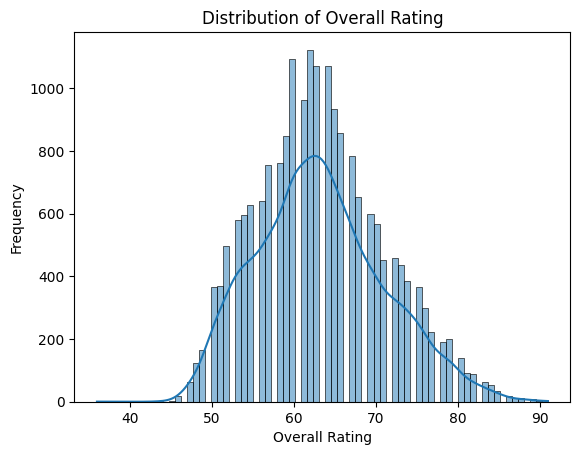

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Overall Rating
plt.figure()
sns.histplot(df['Overall_Rating'], kde=True)
plt.title("Distribution of Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.show()

## Target Variable: Performance Tier

Players are classified into four performance tiers based on the distribution
of Overall Rating using percentiles:
- Bottom 25%  → Low
- 25–50%      → Mid
- 50–75%      → High
- Top 25%     → Elite
``

In [7]:
p25 = df["Overall_Rating"].quantile(0.25)
p50 = df["Overall_Rating"].quantile(0.50)
p75 = df["Overall_Rating"].quantile(0.75)

def assign_tier(r):
    if r < p25:
        return "Low"
    elif r < p50:
        return "Mid"
    elif r < p75:
        return "High"
    else:
        return "Elite"

df["Tier"] = df["Overall_Rating"].apply(assign_tier)

In [8]:
tier_order = ["Low", "Mid", "High", "Elite"]
df["Tier"].value_counts()


Tier
Elite    5352
Low      4807
Mid      4791
High     4717
Name: count, dtype: int64

C:\Users\PC 118\AppData\Local\Temp\ipykernel_13068\2943225307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Tier", data=df, order=["Low", "Mid", "High", "Elite"], palette="Blues_d")


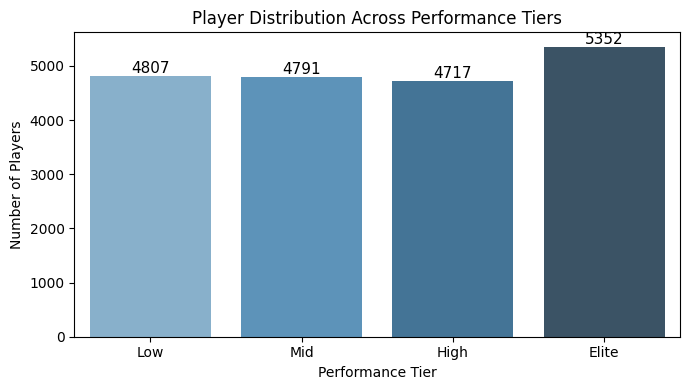

Max/Min class ratio: 1.13
Distribution is BALANCED — percentile-based split ensures roughly equal class sizes.


In [9]:
# Bar chart showing class distribution across performance tiers
plt.figure(figsize=(7, 4))
sns.countplot(x="Tier", data=df, order=["Low", "Mid", "High", "Elite"], palette="Blues_d")
plt.title("Player Distribution Across Performance Tiers")
plt.xlabel("Performance Tier")
plt.ylabel("Number of Players")
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )
plt.tight_layout()
plt.show()

counts = df["Tier"].value_counts()
ratio = counts.max() / counts.min()
print(f"Max/Min class ratio: {ratio:.2f}")
if ratio < 1.5:
    print("Distribution is BALANCED — percentile-based split ensures roughly equal class sizes.")
else:
    print("Distribution is IMBALANCED — consider class_weight='balanced' in the model.")


## Feature Selection

- Target variable: Tier
- Removed:
  - Player Name (non-predictive)
  - Overall Rating (to prevent data leakage)

In [10]:
X = df.drop(columns=["Name", "Overall_Rating", "Tier"])
y = df["Tier"]


## Train-Test Split

Data is split into training and testing sets using stratification
to preserve class balance.
``

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
# Outlier Detection and Handling using IQR (applied on training set only)
num_cols_out = ["Age", "Future Potential", "Total_Stats Score"]

print("=== Outlier Detection (IQR Method) ===")
for col in num_cols_out:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)].shape[0]
    print(f"  {col}: {n_outliers} outliers | lower bound = {lower:.2f}, upper bound = {upper:.2f}")

# Cap outliers using Winsorization (clipping to IQR bounds)
print("\nApplying Winsorization (capping outliers to IQR bounds)...")
for col in num_cols_out:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Outliers capped successfully.")


=== Outlier Detection (IQR Method) ===
  Age: 142 outliers | lower bound = 8.50, upper bound = 36.50
  Future Potential: 99 outliers | lower bound = 52.50, upper bound = 88.50
  Total_Stats Score: 633 outliers | lower bound = 890.00, upper bound = 2218.00

Applying Winsorization (capping outliers to IQR bounds)...
Outliers capped successfully.


## Categorical Encoding

One-Hot Encoding is applied to categorical features since
Logistic Regression requires numerical inputs.

In [13]:
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join="left", axis=1, fill_value=0
)

## Feature Scaling

Standardization is applied to numerical features because
Logistic Regression is sensitive to feature magnitudes.

In [14]:
num_cols = ["Age", "Future Potential", "Total_Stats Score"]

scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])

## Logistic Regression Models

We evaluate multiple Logistic Regression configurations:
- lbfgs solver (baseline multi-class approach)
- One-vs-Rest strategy using the liblinear solver

Performance is compared using accuracy, precision, recall, and F1-score.


--- Logistic Regression (lbfgs) ---
Accuracy : 0.8823
Precision: 0.8840
Recall   : 0.8823
F1-Score : 0.8828



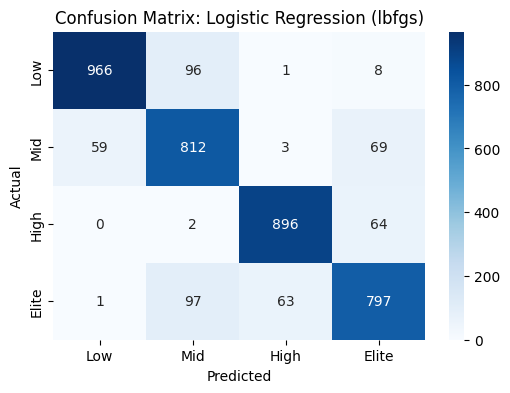

--- Logistic Regression (liblinear OVR) ---
Accuracy : 0.8127
Precision: 0.8142
Recall   : 0.8127
F1-Score : 0.8130



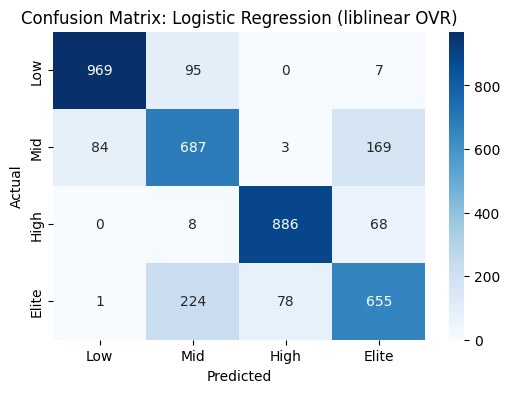

In [15]:
models = {
    "Logistic Regression (lbfgs)": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Logistic Regression (liblinear OVR)": OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
}

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_test_enc)

    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=tier_order,
        yticklabels=tier_order
    )
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

In [16]:
# Detailed per-class classification report for the baseline Logistic Regression model
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline_model.fit(X_train_enc, y_train)
baseline_preds = baseline_model.predict(X_test_enc)

print("=== Per-Class Classification Report (Baseline Logistic Regression) ===")
print(classification_report(baseline_preds, y_test, target_names=["Low", "Mid", "High", "Elite"]))


=== Per-Class Classification Report (Baseline Logistic Regression) ===
              precision    recall  f1-score   support

         Low       0.90      0.94      0.92      1026
         Mid       0.86      0.81      0.83      1007
        High       0.93      0.93      0.93       963
       Elite       0.83      0.85      0.84       938

    accuracy                           0.88      3934
   macro avg       0.88      0.88      0.88      3934
weighted avg       0.88      0.88      0.88      3934



## Regularization in Logistic Regression

Logistic Regression applies regularization to prevent overfitting,
especially when dealing with high-dimensional features produced by
one-hot encoding. The regularization strength is controlled by the
parameter C, which is the inverse of regularization strength.


In [17]:
# Sweep C over a log-spaced range from 10^-3 to 10^3 (20 values)
C_values = np.logspace(-3, 3, 20)

train_acc = []
test_acc  = []

for C in C_values:
    model = LogisticRegression(
        solver="lbfgs",
        C=C,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    model.fit(X_train_enc, y_train)
    train_acc.append(model.score(X_train_enc, y_train))
    test_acc.append(model.score(X_test_enc, y_test))

regularization_df = pd.DataFrame({
    "C": C_values,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc
})

regularization_df


,C,Train Accuracy,Test Accuracy
0,0.001000,0.799021,0.793849
1,0.002069,0.823873,0.820539
2,0.004281,0.839764,0.843416
3,0.008859,0.851268,0.852822
4,0.018330,0.860611,0.860447
5,0.037927,0.872052,0.867311
6,0.078476,0.884637,0.878241
7,0.162378,0.895316,0.882816
8,0.335982,0.906184,0.884596
9,0.695193,0.917752,0.882816


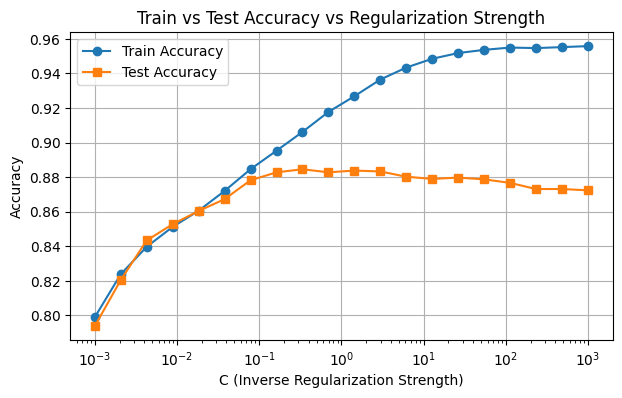

In [18]:
plt.figure(figsize=(7, 4))

plt.plot(regularization_df["C"],
         regularization_df["Train Accuracy"],
         marker='o',
         label="Train Accuracy")

plt.plot(regularization_df["C"],
         regularization_df["Test Accuracy"],
         marker='s',
         label="Test Accuracy")

plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy vs Regularization Strength")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
best_C = regularization_df.loc[
    regularization_df["Test Accuracy"].idxmax(), "C"
]

best_C

np.float64(0.3359818286283781)

In [20]:
# Compare L1 (saga solver) vs L2 (lbfgs solver) at the best C value
models_reg = {
    "L2 - Ridge (lbfgs)": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=best_C,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "L1 - Lasso (saga)": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=best_C,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
}

for name, model in models_reg.items():
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_test_enc)
    print(f"=== {name} ===")
    print(f"  Accuracy : {accuracy_score(y_test, preds):.4f}")
    print(f"  F1-Score : {f1_score(y_test, preds, average='weighted'):.4f}")
    print()


=== L2 - Ridge (lbfgs) ===
  Accuracy : 0.8846
  F1-Score : 0.8851



c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== L1 - Lasso (saga) ===
  Accuracy : 0.8808
  F1-Score : 0.8815



In [21]:
best_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=best_C,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

best_model.fit(X_train_enc, y_train)
final_preds = best_model.predict(X_test_enc)

print(classification_report(y_test, final_preds))


              precision    recall  f1-score   support

       Elite       0.94      0.90      0.92      1071
        High       0.81      0.86      0.84       943
         Low       0.93      0.94      0.93       962
         Mid       0.86      0.84      0.85       958

    accuracy                           0.88      3934
   macro avg       0.88      0.88      0.88      3934
weighted avg       0.89      0.88      0.89      3934



## Detailed Classification Report

The final model, based on L2-regularized Logistic Regression with the lbfgs solver,
is analyzed in detail below.

In [22]:
best_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=best_C,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

best_model.fit(X_train_enc, y_train)
final_preds = best_model.predict(X_test_enc)

print(classification_report(y_test, final_preds, target_names=tier_order))

              precision    recall  f1-score   support

         Low       0.94      0.90      0.92      1071
         Mid       0.81      0.86      0.84       943
        High       0.93      0.94      0.93       962
       Elite       0.86      0.84      0.85       958

    accuracy                           0.88      3934
   macro avg       0.88      0.88      0.88      3934
weighted avg       0.89      0.88      0.89      3934



## Conclusion

Logistic Regression achieved strong performance after tuning the regularization
parameter C. The final model used L2 regularization (Ridge) with the lbfgs solver,
providing stable and efficient convergence on this high-dimensional multi-class
dataset. L2 regularization generally outperformed L1, while most misclassifications
occurred between adjacent performance tiers due to feature overlap.